# 0. starfold, the walkthrough

This notebook is the front door to the package. It takes you from
"I have a matrix of numbers" to "I have a clustering I trust, with
audit panels next to it" and explains each piece in between.
Run the cells top to bottom; you do not need to have read the
source first.

**The story arc.**

1. A real dataset to work with (8x8 handwritten digits).
2. Input validation and sample-size budgets.
3. The one-line `pipeline.fit(X)` and what comes back.
4. The four core building blocks (UMAP/t-SNE/PCA, Optuna-tuned HDBSCAN, trustworthiness).
5. Is this real? Noise baseline and the global credibility test.
6. How stable is it? Chunked silhouette and subsample stability.
7. Every dashboard panel, introduced individually.
8. The two single-call audit dashboards (now every panel is familiar).
9. Refinement after the audit, with a before-and-after comparison.
10. Input-uncertainty handling.
11. Save and reload.

Every public function in `starfold.__all__` is demonstrated at
least once. Demo budgets are intentionally small so the notebook
runs in a few minutes; production budgets are flagged in prose.

## Set-up

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import starfold as sf

FIGURE_DIR = Path("figures") / "tutorial_00_walkthrough"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

print(f"starfold {sf.__version__}")
print(f"public API: {len(sf.__all__)} symbols")
print(f"GPU backend importable: {sf.cuml_is_importable()}")

starfold 0.0.1
public API: 30 symbols
GPU backend importable: False


`sf.cuml_is_importable()` is a one-call check for the RAPIDS GPU
backend. The pipeline defaults to `engine="auto"` and silently uses
the CPU path when cuml is not present.

## §1. The dataset: 1 797 hand-written digits

We will cluster sklearn's built-in `digits` dataset: 1 797 small
8×8 grey-scale images of the digits 0-9. Each image is flattened
to a 64-dimensional feature vector before clustering. The task is
**unsupervised**: starfold never sees the ground-truth digit
labels.

This is a more compelling demo than synthetic blobs because the
clusters are *real classes*, the dimensionality is high enough that
UMAP earns its place, and a few of the digit pairs (4/9, 1/7, 3/8)
are visually confusable, so the clustering will not just return
ten clean classes.

In [2]:
from sklearn.datasets import load_digits  # noqa: E402

digits = load_digits()
X = digits.data.astype(np.float64)  # (1797, 64) — feature matrix
y_truth = digits.target.astype(
    np.intp
)  # (1797,)    — ground-truth digit, used only for reference plots
images = digits.images  # (1797, 8, 8) — image form, for visualisation

print(f"X shape:       {X.shape}")
print(f"y_truth shape: {y_truth.shape}")
print(f"unique classes: {np.unique(y_truth).tolist()}")
print(f"pixel value range: {X.min():.1f} .. {X.max():.1f}")

X shape:       (1797, 64)
y_truth shape: (1797,)
unique classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
pixel value range: 0.0 .. 16.0


### What the raw data looks like

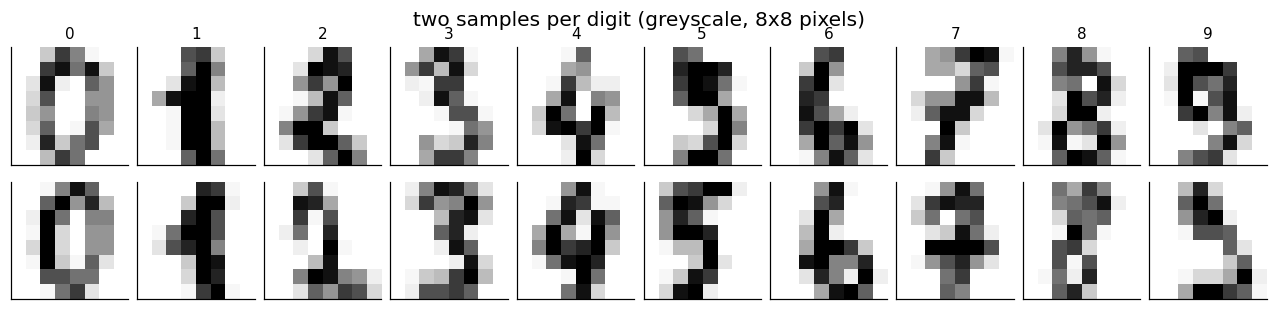

In [3]:
fig, axes = plt.subplots(2, 10, figsize=(11.5, 2.6), constrained_layout=True)
for digit_id in range(10):
    matches = np.where(y_truth == digit_id)[0]
    for row, idx in enumerate(matches[:2]):
        ax = axes[row, digit_id]
        ax.imshow(images[idx], cmap="Greys", vmin=0, vmax=16)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)
        if row == 0:
            ax.set_title(str(digit_id), fontsize=10)
fig.suptitle("two samples per digit (greyscale, 8x8 pixels)", y=1.04)
fig.savefig(FIGURE_DIR / "01_raw_digits.png")
plt.show()

The pixel-intensity range is `0..16` (an artefact of sklearn's
4x4-pixel binning during dataset construction). Clusters in 64-dim
pixel space exist — same-digit images are similar in raw pixel
distance — but they are noisy and overlap. That is exactly the
setting in which a UMAP-and-HDBSCAN pipeline pays off.

## §2. Before fitting: input validation and budgets

### `validate_input_matrix`

Catches the obvious mistakes (`X` is not 2-D, has NaN or inf, has
a constant column, has fewer rows than `n_neighbors`). The pipeline
calls this internally; you can also call it yourself to get a
clear error before paying for a fit.

In [4]:
sf.validate_input_matrix(X, n_neighbors=15)
print("input matrix validated.")

input matrix validated.


### `recommend_budget`

Returns a dictionary of Optuna / noise-baseline budgets that scale
with `n_samples`. The paper's defaults (100 Optuna trials, 1 000
noise realisations × 20 sub-trials each) are right for a production
run on a workstation; smaller samples can use much less.

In [5]:
print(sf.recommend_budget(n_samples=X.shape[0]))

{'hdbscan_optuna_trials': 100, 'n_realisations': 1000, 'per_realisation_trials': 20}


### `auto_mcs_upper`

Caps the upper end of `min_cluster_size` at `max(5, n_samples // 10)`
so the Optuna search does not waste trials on values that exceed the
largest cluster we could possibly recover.

In [6]:
print(f"auto MCS upper bound for N={X.shape[0]}: {sf.auto_mcs_upper(X.shape[0])}")

auto MCS upper bound for N=1797: 89


## §3. The one-line pipeline

`UnsupervisedPipeline.fit(X)` runs the whole story (standardise →
UMAP → Optuna-tuned HDBSCAN → trustworthiness → noise baseline →
credibility test) and returns a single `PipelineResult` that owns
the audit trail.

For this walkthrough we use small budgets:

* `n_epochs=200` for UMAP (paper default is 10 000 for safety; 200
  converges fine on this dataset),
* 40 Optuna trials,
* 12 noise realisations × 5 sub-trials each (paper: 1 000 × 20).

In [7]:
import time  # noqa: E402

pipeline = sf.UnsupervisedPipeline(
    umap_kwargs=dict(n_neighbors=15, min_dist=0.0, n_epochs=200),
    hdbscan_optuna_trials=40,
    random_state=0,
    noise_baseline_kwargs=dict(
        n_realisations=12,
        per_realisation_trials=5,
    ),
)

t0 = time.perf_counter()
result = pipeline.fit(X)
print(f"pipeline.fit took {time.perf_counter() - t0:.1f}s")

pipeline.fit took 31.6s


/tmp/ipykernel_1661227/261854649.py:14: UserWarning: Optuna best was reached 32 trials before the end of the 40-trial budget; consider halving n_trials on similar runs to save compute.
  result = pipeline.fit(X)


### `result.summary()` — the printable verdict

In [8]:
print(result.summary())

!! diagnostic flags
--------------------------------
- Optuna best was reached 32 trials before the end of the 40-trial budget; consider halving n_trials on similar runs to save compute.

starfold pipeline result
--------------------------------
n_samples        1797
n_clusters       11
n_outliers       53  (2.9%)
trustworthiness  0.9723
continuity       0.9746
objective        persistence_sum
best_params      {'min_cluster_size': 62, 'min_samples': 2, 'cluster_selection_method': 'eom', 'cluster_selection_epsilon': 0.43698005437162596, 'alpha': 1.3751492373342808}
persistence_sum  6.9165
persistence_med  0.6590
DBCV (MST proxy) 0.7560
noise_threshold  0.4693
significant      9/11
credibility      FAIL at alpha=0.003  p(n_clusters)=0.6154  p(persistence_sum)=0.2308  p(max_persistence)=0.0769
per-cluster      9/11 clusters credible
persistence      [0.838 0.738 0.659 0.451 0.517 0.6   0.435 0.81  0.666 0.515 0.688]


### The embedding, coloured by HDBSCAN label

`plot_embedding` is the workhorse: a scatter of the 2-D UMAP
layout, coloured by HDBSCAN cluster, outliers in grey.

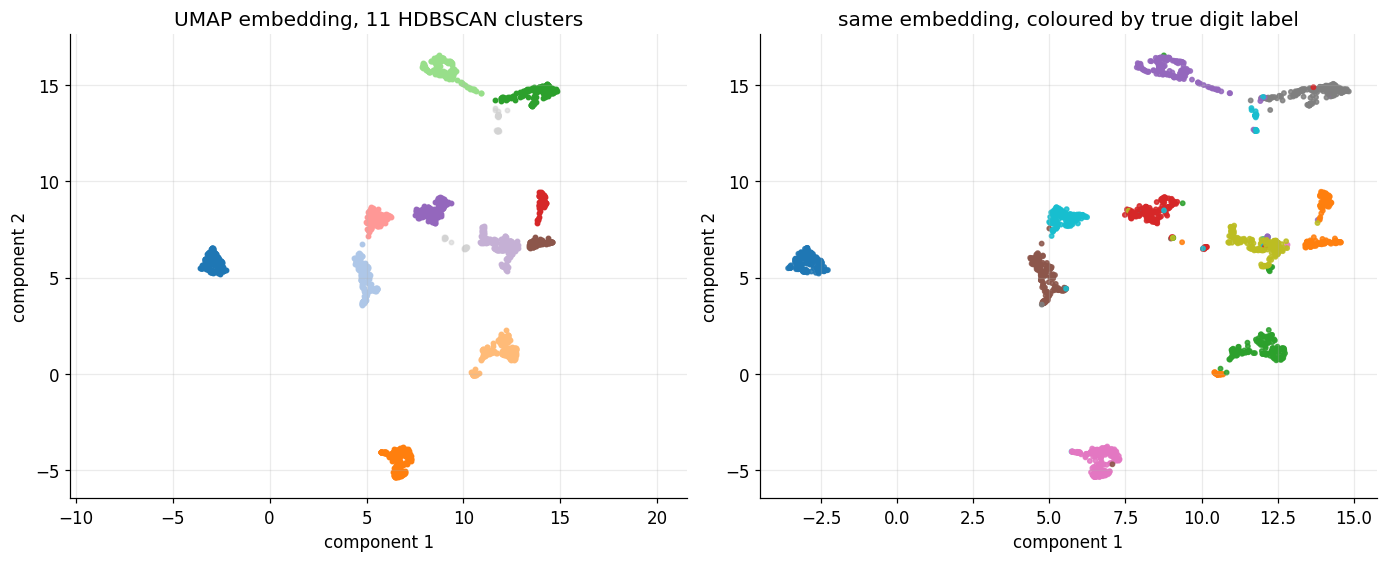

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.0), constrained_layout=True)
sf.plot_embedding(result.embedding, result.labels, ax=axes[0])
axes[0].set_title(f"UMAP embedding, {result.n_clusters} HDBSCAN clusters")
axes[1].scatter(
    result.embedding[:, 0], result.embedding[:, 1], c=y_truth, cmap="tab10", s=8, alpha=0.85
)
axes[1].set_xlabel("component 1")
axes[1].set_ylabel("component 2")
axes[1].set_title("same embedding, coloured by true digit label")
fig.savefig(FIGURE_DIR / "02_pipeline_embedding.png")
plt.show()

Left: HDBSCAN's unsupervised labels. Right: the same points,
coloured by the *true* digit. The pipeline recovers most digit
classes; the visually-confusable pairs (e.g. 1/9, 4/9, 3/8) may
be merged into single clusters or split unevenly.

### What lives on the result

`PipelineResult` is an immutable dataclass that owns every artefact
the pipeline produced. The most-used attributes:

In [10]:
print(f"embedding shape:    {result.embedding.shape}")
print(f"labels (unique):    {np.unique(result.labels).tolist()}")
print(f"persistence:        {[round(float(p), 3) for p in result.persistence]}")
print(f"trustworthiness:    {result.trustworthiness:.4f}")
print(f"continuity:         {result.continuity:.4f}")
print(f"n outliers:         {int(np.sum(result.labels == -1))}")
print(f"flags (empty if OK): {result.flags or '(none)'}")

embedding shape:    (1797, 2)
labels (unique):    [-1, 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
persistence:        [0.838, 0.738, 0.659, 0.451, 0.517, 0.6, 0.435, 0.81, 0.666, 0.515, 0.688]
trustworthiness:    0.9723
continuity:         0.9746
n outliers:         53
flags (empty if OK): ['Optuna best was reached 32 trials before the end of the 40-trial budget; consider halving n_trials on similar runs to save compute.']


## §4. The four core building blocks

The pipeline orchestrates four independent primitives. Each is
also a public function callable with the same kwargs.

### §4a. Manifold learning: `run_umap`, `run_tsne`, `run_pca`

All three live in `starfold.embedding`. They are thin wrappers
around the standard implementations and exist mainly to thread the
`random_state` and the GPU `engine` selector through consistently.

Note: `run_umap` does not standardise its input (the pipeline does
this via `StandardScaler` before calling it). For a fair side-by-side
we scale once and reuse.

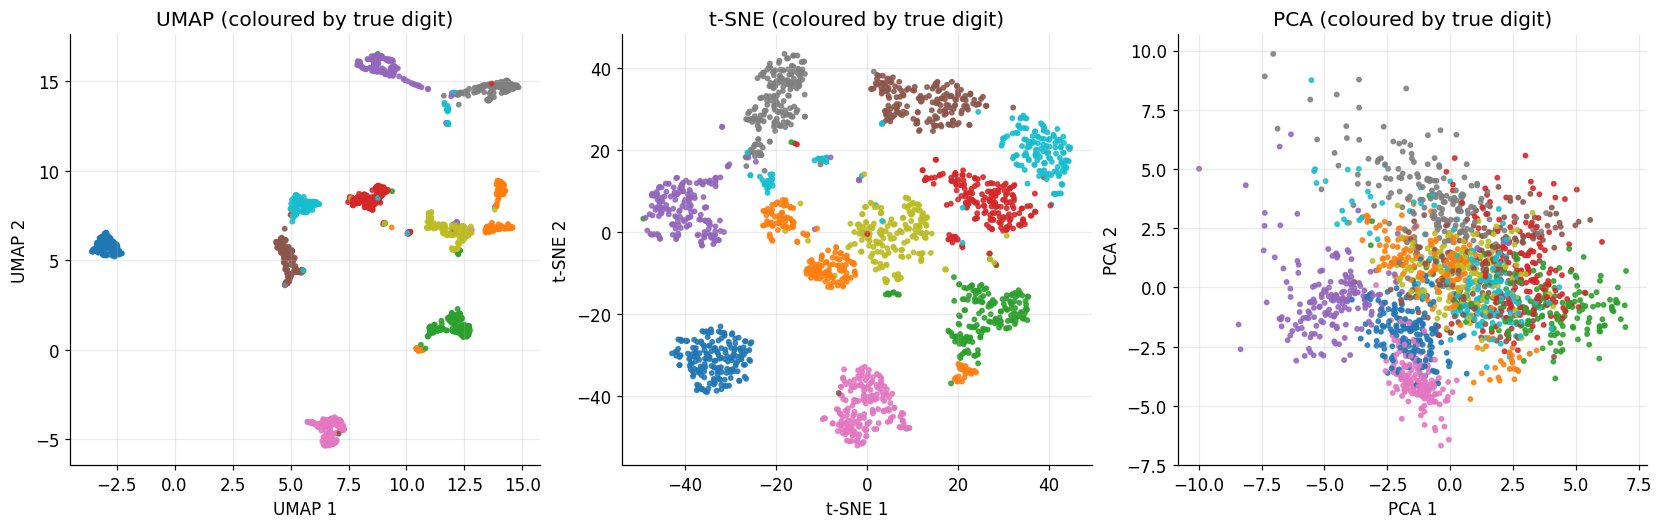

In [11]:
from sklearn.preprocessing import StandardScaler  # noqa: E402

X_scaled = StandardScaler().fit_transform(X)

emb_umap = sf.run_umap(X_scaled, n_neighbors=15, min_dist=0.0, n_epochs=200, random_state=0)
emb_tsne = sf.run_tsne(X_scaled, perplexity=30, n_iter=1_000, random_state=0)
emb_pca = sf.run_pca(X_scaled, n_components=2, random_state=0)

fig, axes = plt.subplots(1, 3, figsize=(15.0, 4.7), constrained_layout=True)
for ax, (name, emb) in zip(axes, [("UMAP", emb_umap), ("t-SNE", emb_tsne), ("PCA", emb_pca)]):
    ax.scatter(emb[:, 0], emb[:, 1], c=y_truth, cmap="tab10", s=8, alpha=0.85)
    ax.set_xlabel(f"{name} 1")
    ax.set_ylabel(f"{name} 2")
    ax.set_title(f"{name} (coloured by true digit)")
fig.savefig(FIGURE_DIR / "03_embedding_comparison.png")
plt.show()

UMAP gives ten well-separated islands. t-SNE finds similar
topology but lets neighbouring classes touch. PCA captures only
the largest-variance direction and collapses several classes on
top of each other. The pipeline uses UMAP because it is the most
cluster-preserving of the three on this kind of data.

### `plot_embedding_comparison`: the same idea, one helper call

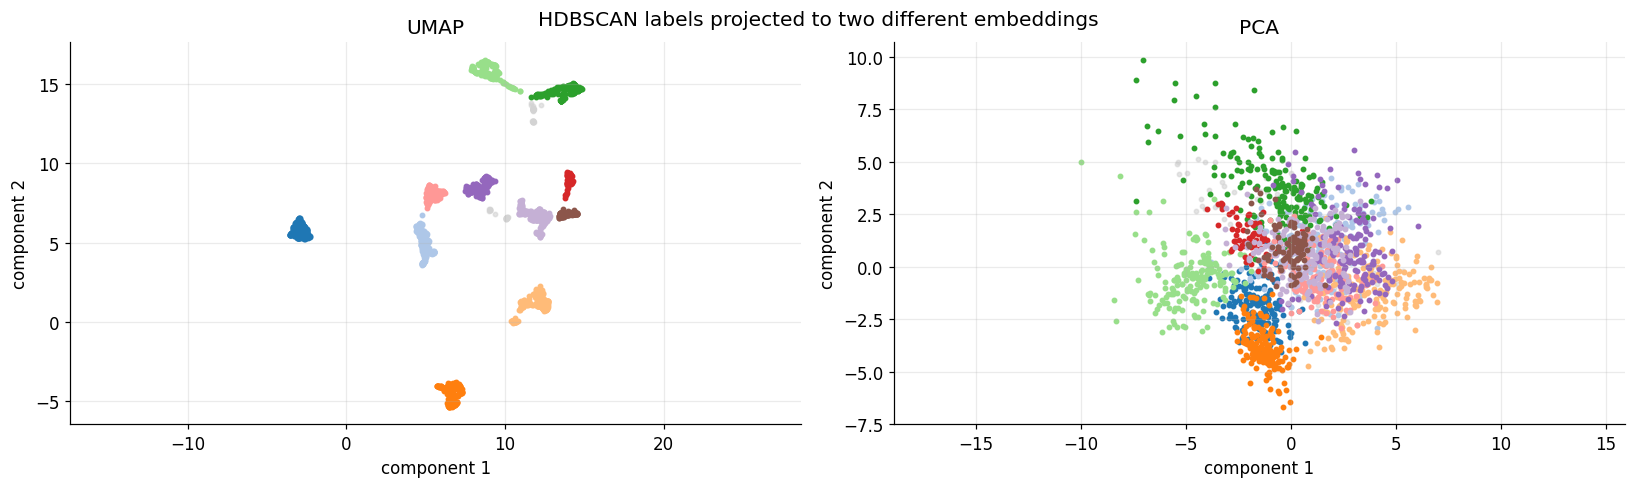

In [12]:
fig, _ = sf.plot_embedding_comparison(
    {"UMAP": emb_umap, "PCA": emb_pca},
    labels=result.labels,
)
fig.suptitle("HDBSCAN labels projected to two different embeddings")
fig.savefig(FIGURE_DIR / "04_embedding_comparison_helper.png")
plt.show()

### §4b. Clustering one config: `run_hdbscan`

`run_hdbscan(emb, min_cluster_size=...)` runs a single HDBSCAN fit
without any hyperparameter search. Useful when you have a domain
prior on cluster size, or to spot-check the Optuna pick.

In [13]:
hd = sf.run_hdbscan(emb_umap, min_cluster_size=30, min_samples=10)
print(f"clusters found:      {hd.n_clusters}")
print(f"persistence per cl.: {[round(float(p), 3) for p in hd.cluster_persistence]}")
print(f"outliers:            {int(np.sum(hd.labels == -1))} / {hd.labels.size}")

clusters found:      11
persistence per cl.: [0.455, 0.713, 0.48, 0.368, 0.364, 0.397, 0.568, 0.652, 0.494, 0.615, 0.284]
outliers:            21 / 1797


### §4c. Hyperparameter search: `search_hdbscan`

When you do not know the right `min_cluster_size`, Optuna sweeps
it (plus `min_samples`, cluster selection method, epsilon, alpha)
and maximises the sum of cluster persistences. The same routine
runs inside `UnsupervisedPipeline.fit`. The return value carries
the `optuna.Study`, the best parameters, and a refit HDBSCAN.

In [14]:
search = sf.search_hdbscan(emb_umap, n_trials=40, random_state=0)
print(f"best params: {search.best_params}")
print(f"best persistence sum: {search.best_persistence_sum:.4f}")
print(f"final fit: {search.hdbscan_result.n_clusters} clusters")

best params: {'min_cluster_size': 40, 'min_samples': 13, 'cluster_selection_method': 'leaf', 'cluster_selection_epsilon': 0.37218310843243796, 'alpha': 1.3659400462533897}
best persistence sum: 6.7177
final fit: 12 clusters


### §4d. Embedding quality: trustworthiness and continuity

A trustworthy embedding does not invent neighbourhoods that are
not in the input; a continuous embedding does not destroy
neighbourhoods that are. Both range in `[0, 1]`; ~0.9 or higher is
the paper's heuristic for a healthy fit.

`trustworthiness(X_high, X_low, k=...)` and the dual `continuity`
return single scalars. Their `_curve` siblings vectorise across
many $k$ values for the cost of one top-$k$ kNN query.

In [15]:
print(f"T(k=15) = {sf.trustworthiness(X_scaled, result.embedding, k=15):.4f}")
print(f"C(k=15) = {sf.continuity(X_scaled, result.embedding, k=15):.4f}")

T(k=15) = 0.9723


C(k=15) = 0.9746


## §5. Is the clustering real, or noise?

HDBSCAN finds at least one cluster on almost any input including
pure Gaussian noise. Two questions therefore matter:

1. **Per-cluster.** Is this cluster's persistence higher than what
   noise typically produces?
2. **Per-run.** Is the run-level summary (cluster count, best
   Optuna objective, strongest persistence) jointly distinguishable
   from noise?

starfold answers both.

### §5a. `compute_noise_baseline`

Generates `n_realisations` independent Gaussian matrices of the
same shape as the data, runs UMAP and Optuna-tuned HDBSCAN on
each, and records the maximum cluster persistence per realisation.
The 99.7th percentile of those maxima is the 3σ threshold a real
cluster must clear to be flagged `significant`.

The full result is reused automatically by `pipeline.fit` when
`noise_baseline_kwargs` is set; we recompute here only to show the
raw call.

In [16]:
baseline = sf.compute_noise_baseline(
    n_samples=X.shape[0],
    n_features=X.shape[1],
    umap_kwargs=dict(n_neighbors=15, min_dist=0.0, n_epochs=200),
    n_realisations=12,
    per_realisation_trials=5,
    random_state=0,
)
print(f"99.7th-percentile threshold: {baseline.threshold:.4f}")
print(f"observed persistences:       {[round(float(p), 3) for p in result.persistence]}")
print(f"clusters above threshold:    {int(np.sum(result.significant))} / {len(result.significant)}")

99.7th-percentile threshold: 0.4693
observed persistences:       [0.838, 0.738, 0.659, 0.451, 0.517, 0.6, 0.435, 0.81, 0.666, 0.515, 0.688]
clusters above threshold:    9 / 11


### §5b. `compute_credibility` (the omnibus 3σ test)

`compute_credibility` aggregates three per-run scalars against
their noise nulls. Each scalar has a one-sided upper-tail empirical
p-value (Phipson & Smyth 2010 correction). The run "passes" at 3σ
when all three p-values clear `alpha=0.003`.

The pipeline already populated `result.credibility`; we call the
function directly to show what comes back.

In [17]:
report = sf.compute_credibility(
    n_clusters=result.n_clusters,
    best_objective=result.search.best_persistence_sum,
    max_persistence=float(result.persistence.max()),
    baseline=baseline,
    cluster_persistence=result.persistence,
)
print(report.summary())

credibility at alpha=0.003: FAIL
  n_clusters      obs=11  null-median=9  p=0.4615
  persistence_sum obs=6.9165  null-median=0.6507  p=0.2308
  max_persistence obs=0.8380  null-median=0.2242  p=0.0769
  per-cluster     9/11 clusters credible at alpha=0.003


## §6. Stability and robustness

Two cheap audits address "would this clustering hold up?".

### §6a. `chunked_silhouette`

Silhouette compares each sample's mean distance to its own cluster
against its mean distance to the nearest foreign cluster. The
textbook implementation materialises the full N x N distance
matrix — at $N = 1797$ that is fine, but for $N \geq 10^4$ it is
already 800 MB. `chunked_silhouette` streams the row blocks and
returns the overall score, the per-sample array, and per-cluster
means.

In [18]:
sil = sf.chunked_silhouette(result.embedding, result.labels, chunk_size=256)
print(f"overall silhouette: {sil.overall:.3f}")
for c, (s, n) in enumerate(zip(sil.per_cluster, sil.cluster_sizes)):
    print(f"  cluster {c}: silhouette={s:.3f}, size={n}")

overall silhouette: 0.773
  cluster 0: silhouette=0.924, size=178
  cluster 1: silhouette=0.677, size=181
  cluster 2: silhouette=0.898, size=182
  cluster 3: silhouette=0.798, size=192
  cluster 4: silhouette=0.787, size=182
  cluster 5: silhouette=0.797, size=173
  cluster 6: silhouette=0.767, size=65
  cluster 7: silhouette=0.805, size=143
  cluster 8: silhouette=0.757, size=171
  cluster 9: silhouette=0.534, size=184
  cluster 10: silhouette=0.756, size=93


### §6b. `compute_subsample_stability`

Refits HDBSCAN on random subsamples of the 2-D embedding and
reports the Adjusted Rand Index (ARI) of each refit's labels
against the full-sample labels, plus the cluster-count distribution
across subsamples. A stable fit gives ARI close to 1 and a tight
`n_clusters` distribution.

In [19]:
stability = sf.compute_subsample_stability(
    embedding=result.embedding,
    reference_labels=result.labels,
    reference_persistence=result.persistence,
    min_cluster_size=int(result.best_params["min_cluster_size"]),
    min_samples=int(result.best_params["min_samples"]),
    cluster_selection_method=str(result.best_params.get("cluster_selection_method", "eom")),
    n_subsamples=10,
    subsample_fraction=0.8,
    random_state=0,
)
print(
    f"ARI: min={stability.ari.min():.3f}, "
    f"median={float(np.median(stability.ari)):.3f}, "
    f"max={stability.ari.max():.3f}"
)
print(f"n_clusters across subsamples: {stability.n_clusters.tolist()}")

ARI: min=0.998, median=1.000, max=1.000
n_clusters across subsamples: [10, 10, 10, 10, 10, 10, 10, 10, 10, 10]


## §7. Every dashboard panel, introduced individually

starfold's two single-call audit dashboards (next section) are
composed of 14 panels. Before reading the dashboards, here is
every panel as a standalone plot, with the one-sentence "what to
read off it" guide.

### §7a. Tuning panels (8 panels, in dashboard order)

These all live in `starfold.plotting`. Each takes the Optuna study
from `result.search.study` (or `search.study` from a direct
`search_hdbscan` call).

**(a) Optuna history.** Running-best objective over trials. Should
rise quickly and plateau; a long flat tail says the budget was
sufficient.

**(b-c) Pareto fronts.** Two pairs of objectives: sum of cluster
persistence vs HDBSCAN's DBCV proxy, and median persistence vs
the same. Each point is one trial; the star is the trial Optuna
picked.

**(d) Hyperparameter landscape.** Trials projected into
`(min_cluster_size, min_samples)` space (log-log), coloured by
persistence. The star is the pick.

**(e) Granularity-stability trade-off.** Per-trial cluster count vs
persistence sum, coloured by DBCV. Helps spot the "two clusters at
high persistence vs ten clusters at lower persistence" choice.

**(f) Parallel coordinates.** All five tuned hyperparameters on
one axis each, lines coloured by persistence. Surfaces correlated
choices.

**(g) Condensed tree.** HDBSCAN's internal merge tree at the
selected fit. Tall, narrow branches are stable clusters.

**(h) fANOVA parameter importance.** Variance decomposition of the
objective across hyperparameters.

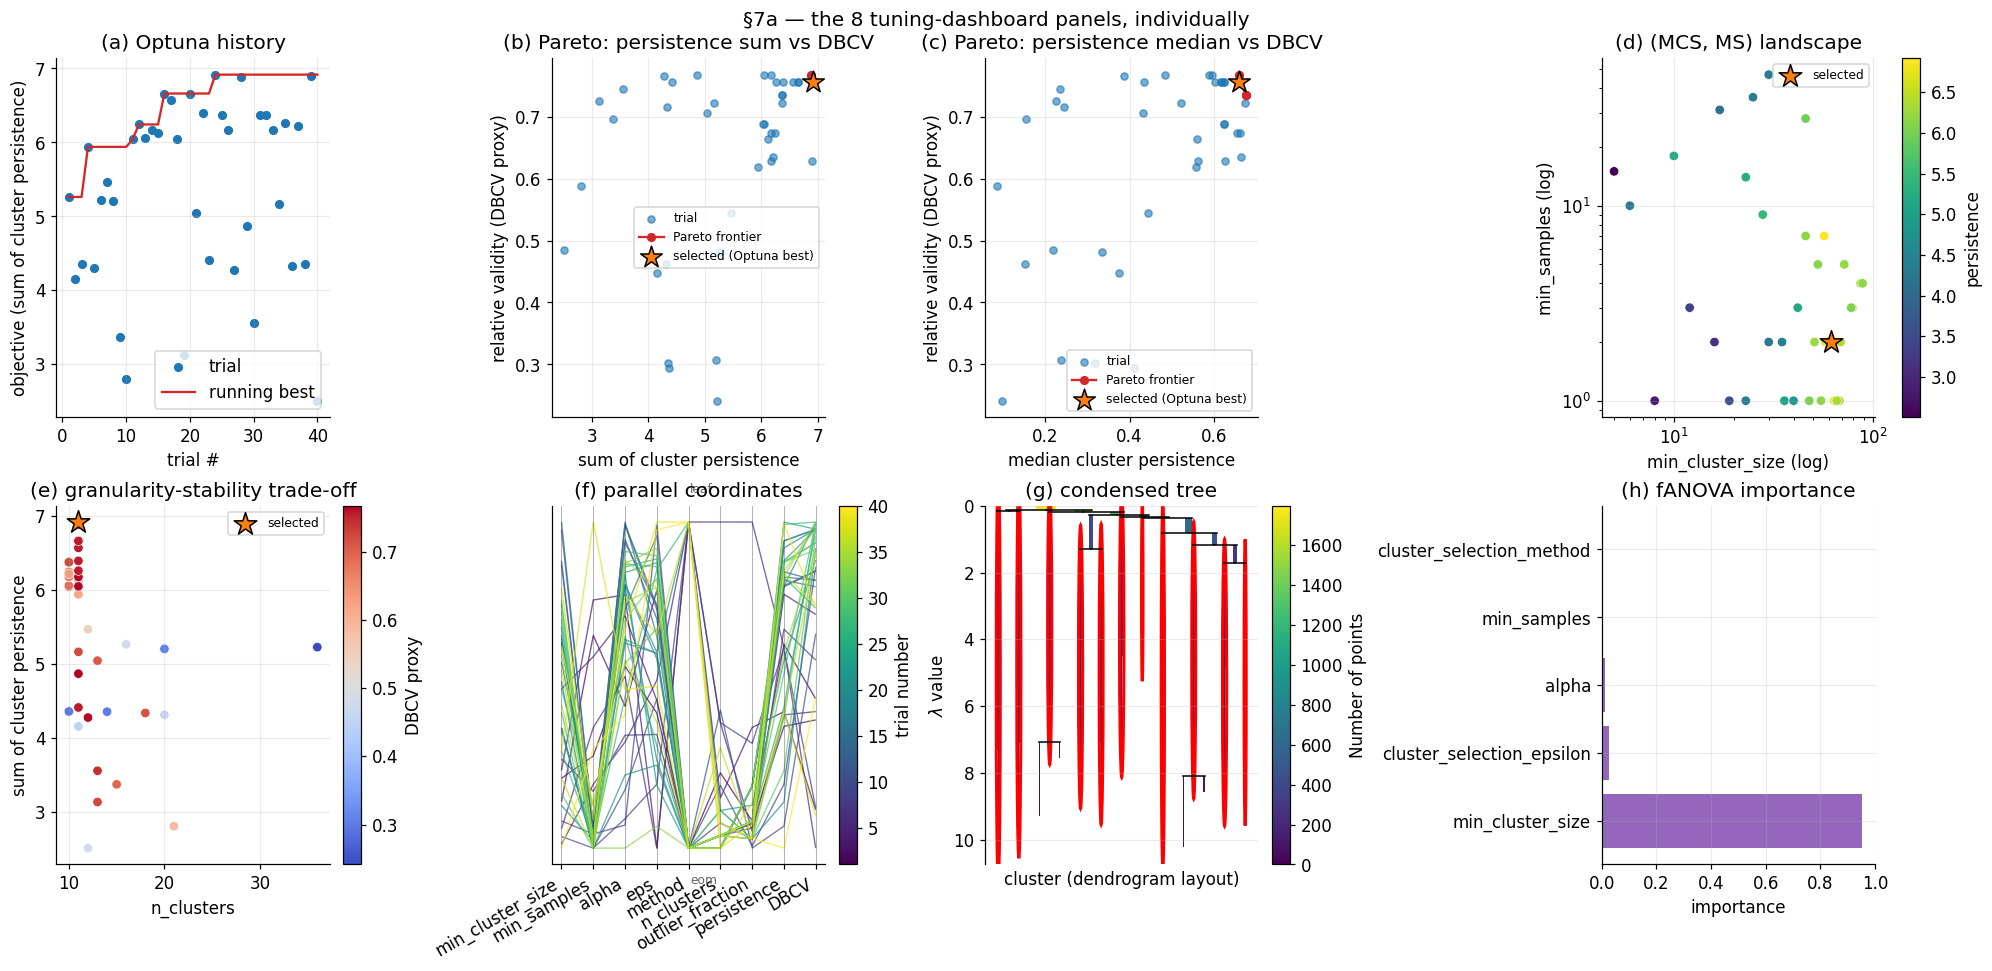

In [20]:
from starfold.plotting import (  # noqa: E402
    plot_granularity_stability,
    plot_optuna_hyperparam_landscape,
    plot_optuna_parallel,
    plot_optuna_pareto,
)

study = result.search.study

fig, axes = plt.subplots(2, 4, figsize=(18.0, 8.5), constrained_layout=True)
sf.plot_optuna_history(study, ax=axes[0, 0])
axes[0, 0].set_title("(a) Optuna history")

plot_optuna_pareto(
    study,
    x_metric="persistence_sum",
    y_metric="relative_validity",
    ax=axes[0, 1],
)
axes[0, 1].set_title("(b) Pareto: persistence sum vs DBCV")

plot_optuna_pareto(
    study,
    x_metric="persistence_median",
    y_metric="relative_validity",
    ax=axes[0, 2],
)
axes[0, 2].set_title("(c) Pareto: persistence median vs DBCV")

plot_optuna_hyperparam_landscape(study, ax=axes[0, 3])
axes[0, 3].set_title("(d) (MCS, MS) landscape")

plot_granularity_stability(study, ax=axes[1, 0])
axes[1, 0].set_title("(e) granularity-stability trade-off")

plot_optuna_parallel(study, ax=axes[1, 1])
axes[1, 1].set_title("(f) parallel coordinates")

sf.plot_condensed_tree(result.search.model, ax=axes[1, 2])
axes[1, 2].set_title("(g) condensed tree")

sf.plot_optuna_param_importance(study, ax=axes[1, 3])
axes[1, 3].set_title("(h) fANOVA importance")
fig.suptitle("§7a — the 8 tuning-dashboard panels, individually", y=1.02)
fig.savefig(FIGURE_DIR / "05_tuning_panels_individually.png")
plt.show()

### §7b. Quality panels (6 panels, in dashboard order)

These audit the *result*, not the search.

**(a) HDBSCAN membership-probability map.** HDBSCAN reports a
per-sample probability of belonging to its assigned cluster; this
panel colours the embedding by that probability. Low confidence
means a point sits on a cluster boundary.

**(b) fANOVA parameter importance.** Same panel as tuning-(h);
included here because it answers a different question
("which knobs would I move if the run were sub-optimal?").

**(c) Trustworthiness / continuity curves.** T(k) and C(k) over a
k-grid; the 0.90 heuristic is marked.

**(d) `n_clusters` distribution under subsampling.** Histogram
from §6b: how many clusters does HDBSCAN find on each 80 %-resample
of the embedding?

**(e) ARI distribution under subsampling.** Companion to (d):
how similar are the subsample labels to the reference labels?

**(f) Per-cluster persistence under subsampling.** Box-plot of
persistence values seen by each reference cluster across the
subsamples, with the full-sample persistence overlaid.

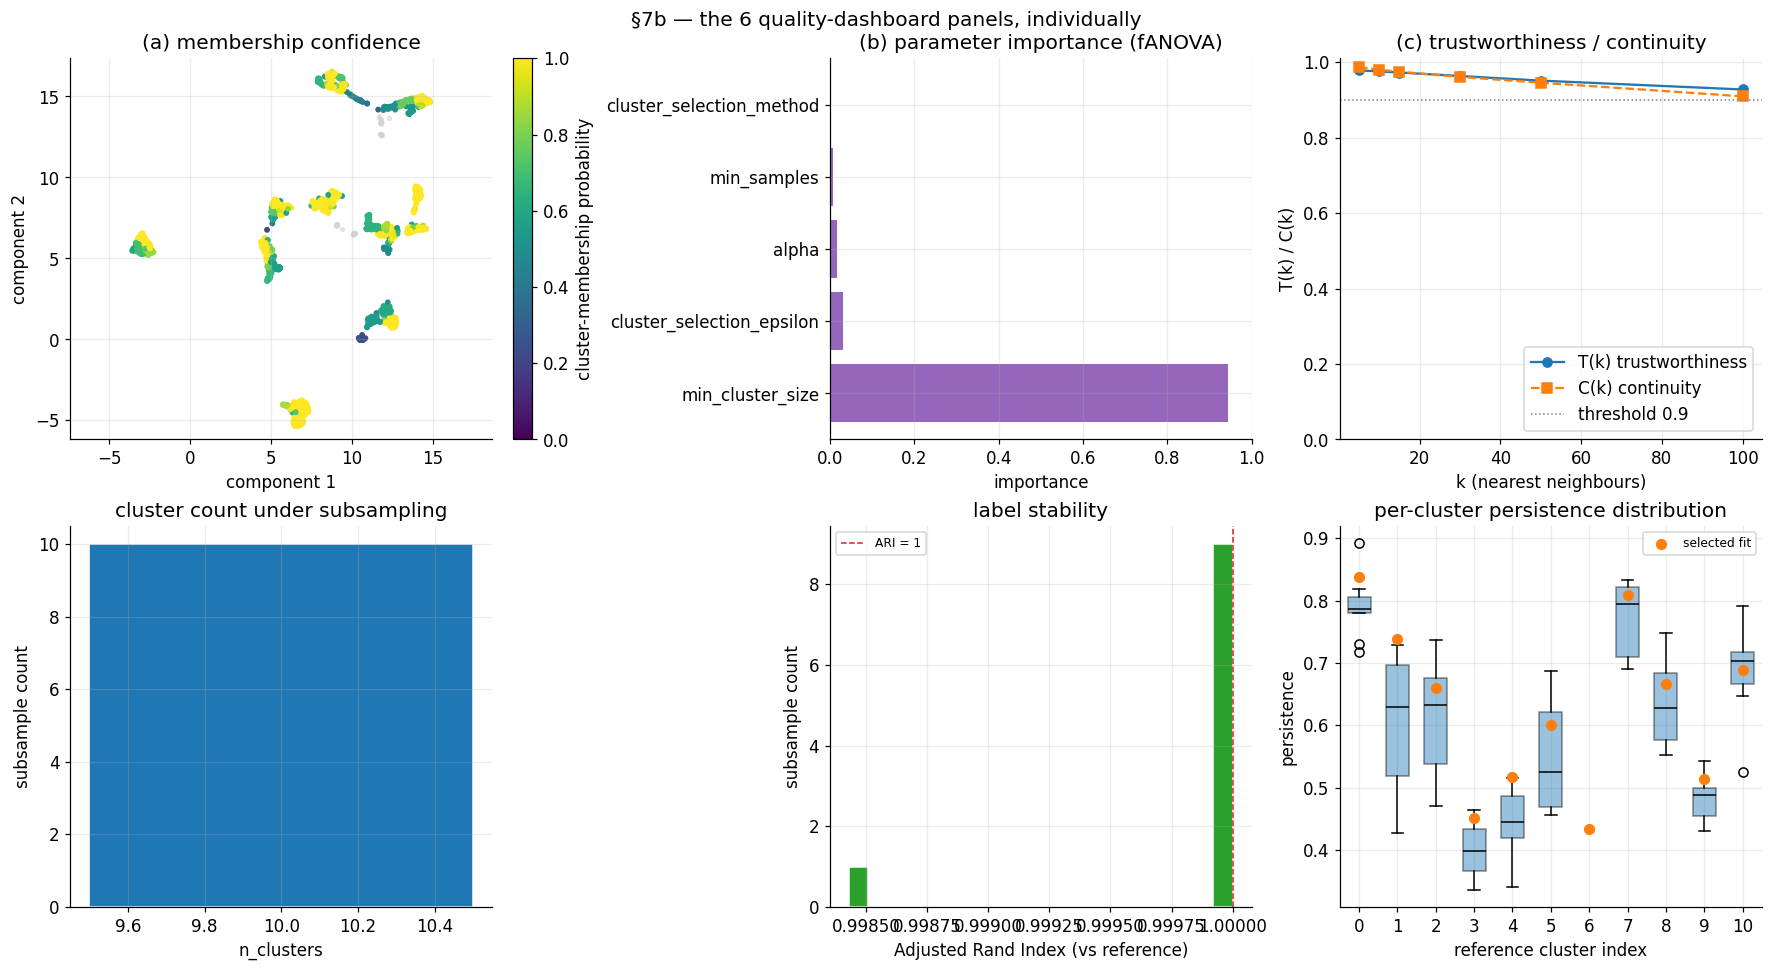

In [21]:
from starfold.plotting import (  # noqa: E402
    plot_membership_confidence,
    plot_subsample_stability,
)

# Inputs the dashboard panels need:
k_values = (5, 10, 15, 30, 50, 100)
trust = sf.trustworthiness_curve(X_scaled, result.embedding, k_values=k_values)
cont = sf.continuity_curve(X_scaled, result.embedding, k_values=k_values)

fig, axes = plt.subplots(2, 3, figsize=(16.0, 8.5), constrained_layout=True)
plot_membership_confidence(
    result.embedding,
    result.labels,
    result.probabilities,
    ax=axes[0, 0],
)
axes[0, 0].set_title("(a) membership confidence")

sf.plot_optuna_param_importance(study, ax=axes[0, 1])
axes[0, 1].set_title("(b) parameter importance (fANOVA)")

sf.plot_trustworthiness_curve(trust, continuity_scores=cont, ax=axes[0, 2])
axes[0, 2].set_title("(c) trustworthiness / continuity")

plot_subsample_stability(
    stability,
    result.persistence,
    axes=[axes[1, 0], axes[1, 1], axes[1, 2]],
)
fig.suptitle("§7b — the 6 quality-dashboard panels, individually", y=1.02)
fig.savefig(FIGURE_DIR / "06_quality_panels_individually.png")
plt.show()

Two "embedding-view" panels live outside the quality dashboard but
pair well with it:

* `plot_embedding(result.embedding, result.labels)` — the classic
  coloured-by-cluster scatter (covered in §3).
* `plot_uncertainty_map(embedding, propagation)` — the same scatter
  coloured by instability under input noise (covered in §10a
  below, after the uncertainty machinery is introduced).

Two extra "per-cluster" panels live in `starfold.plotting` and
are useful next to the dashboards even though they are not in
them:

* `plot_persistence_vs_baseline` — bar chart of per-cluster
  persistence with the noise-baseline threshold marked.
* `plot_per_cluster_credibility` — same, but with the full
  per-cluster p-value strip from `compute_credibility`.

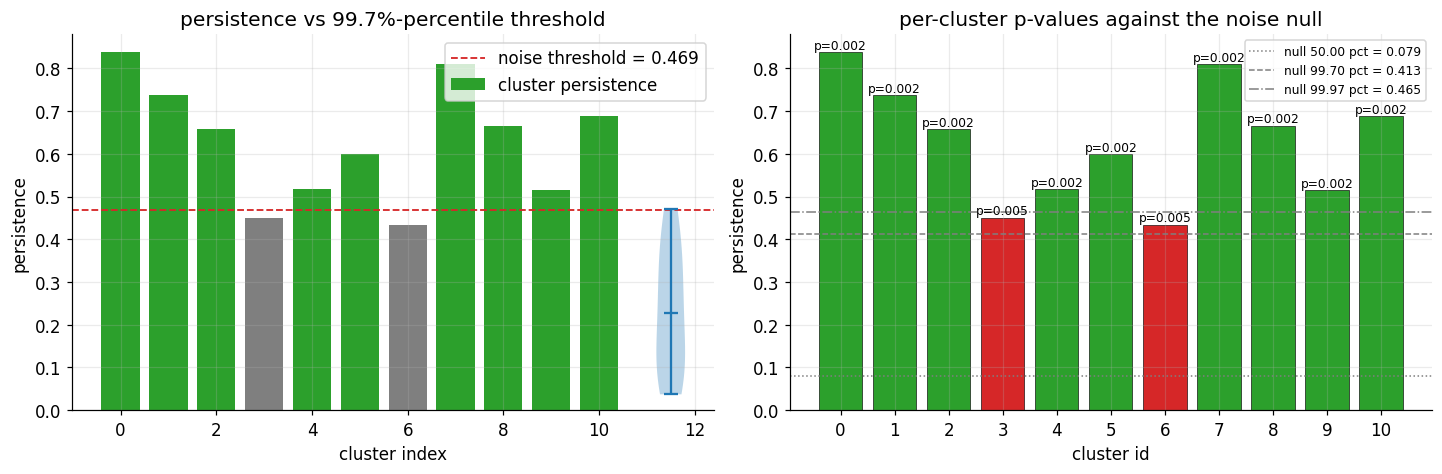

In [22]:
from starfold.plotting import (  # noqa: E402
    plot_per_cluster_credibility,
    plot_persistence_vs_baseline,
)

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.2), constrained_layout=True)
plot_persistence_vs_baseline(
    result.persistence,
    baseline=baseline.threshold,
    per_realisation_max=baseline.per_realisation_max,
    ax=axes[0],
)
axes[0].set_title("persistence vs 99.7%-percentile threshold")

plot_per_cluster_credibility(report, ax=axes[1])
axes[1].set_title("per-cluster p-values against the noise null")
fig.savefig(FIGURE_DIR / "07_per_cluster_audits.png")
plt.show()

## §8. The two single-call audit dashboards

Every panel above is in one of these two figures. They exist so
you can render the audit trail of any run with one method call.

### §8a. `result.plot_tuning_dashboard()` — 8 panels on one canvas

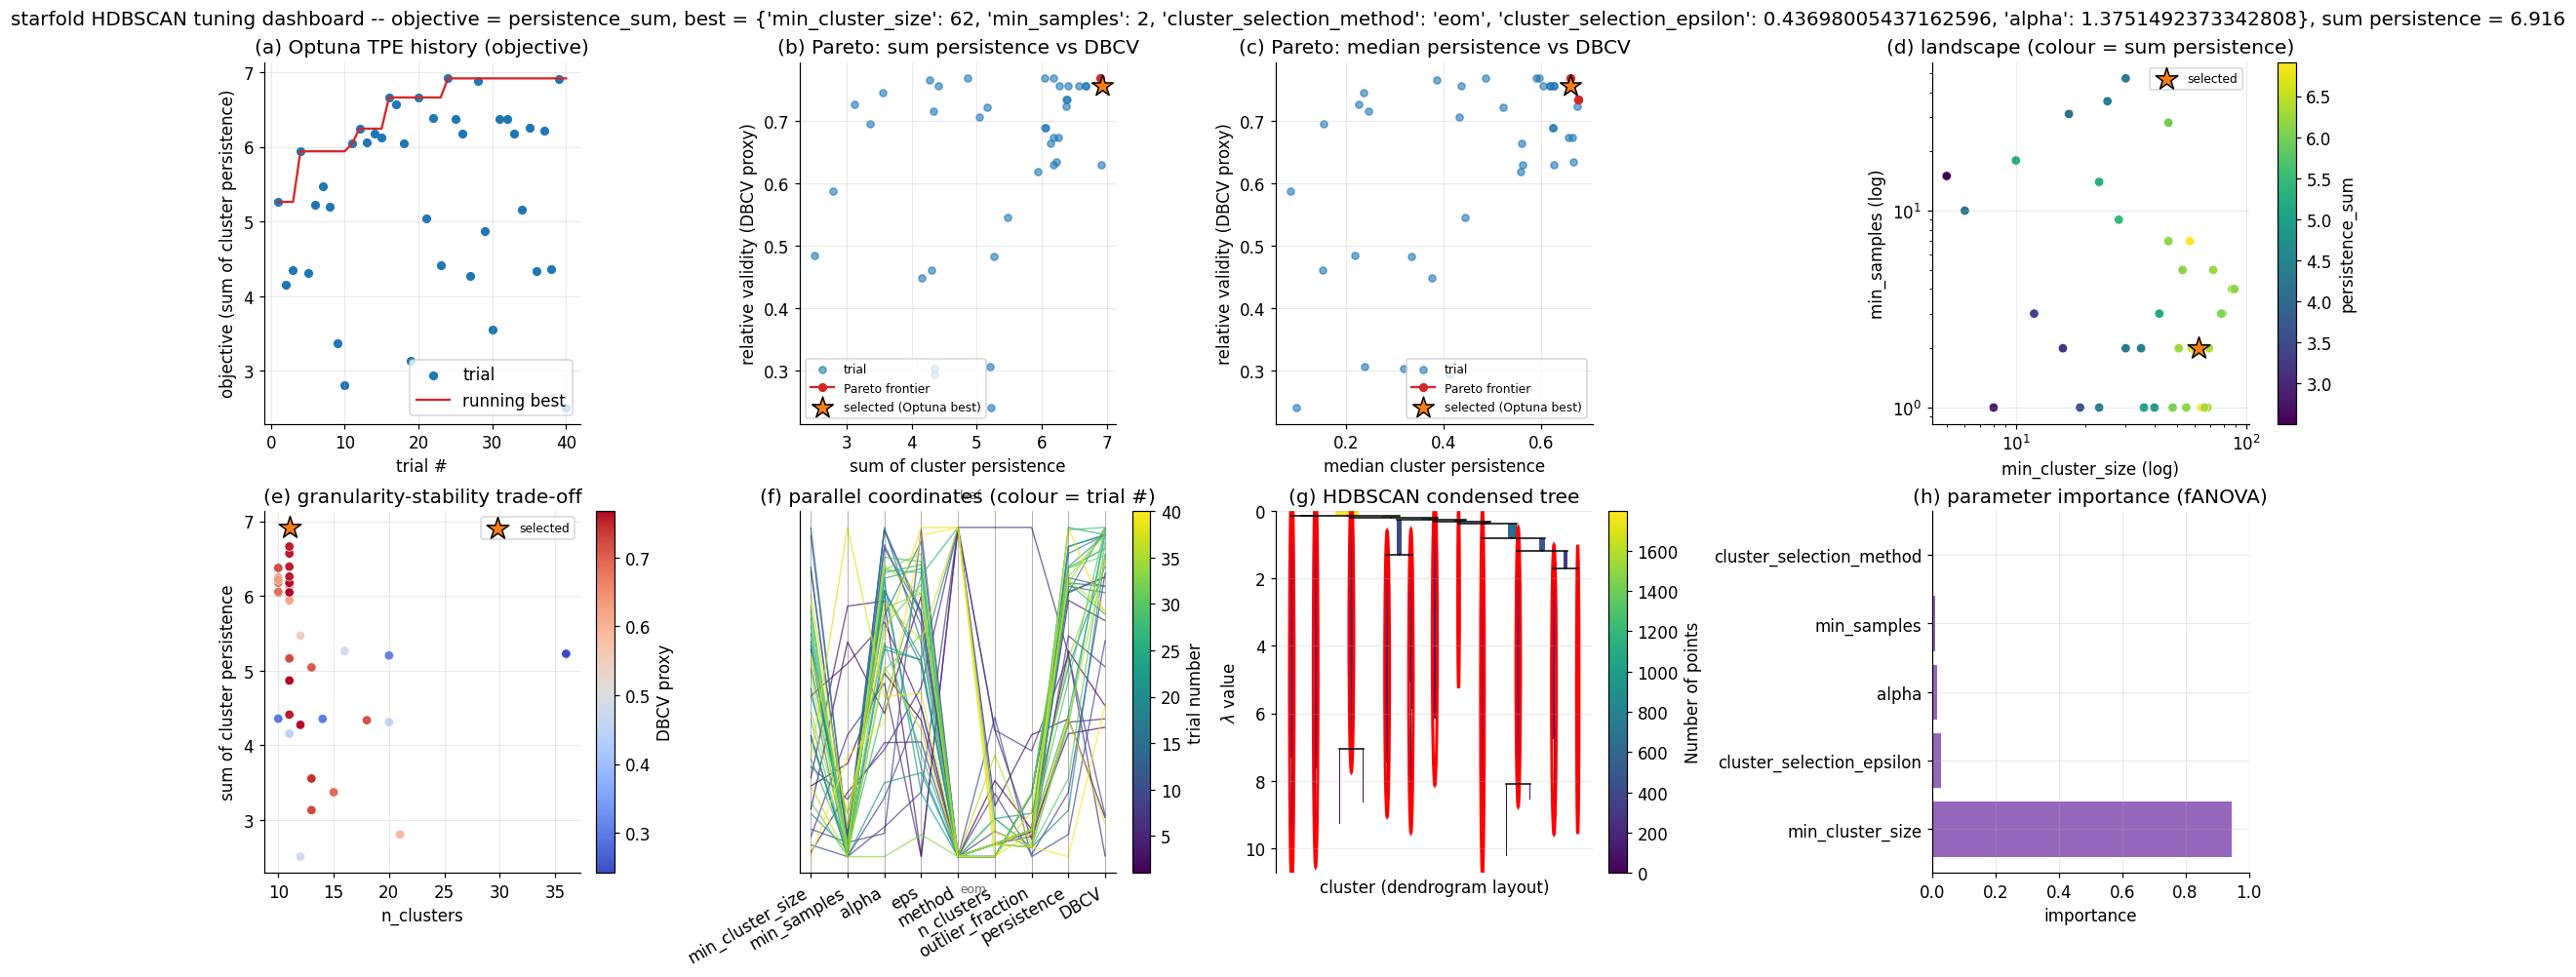

In [23]:
fig = result.plot_tuning_dashboard(figsize=(20.0, 9.0))
fig.savefig(FIGURE_DIR / "08_tuning_dashboard.png")
plt.show()

### §8b. `result.plot_quality_dashboard(X)` — 6 panels on one canvas

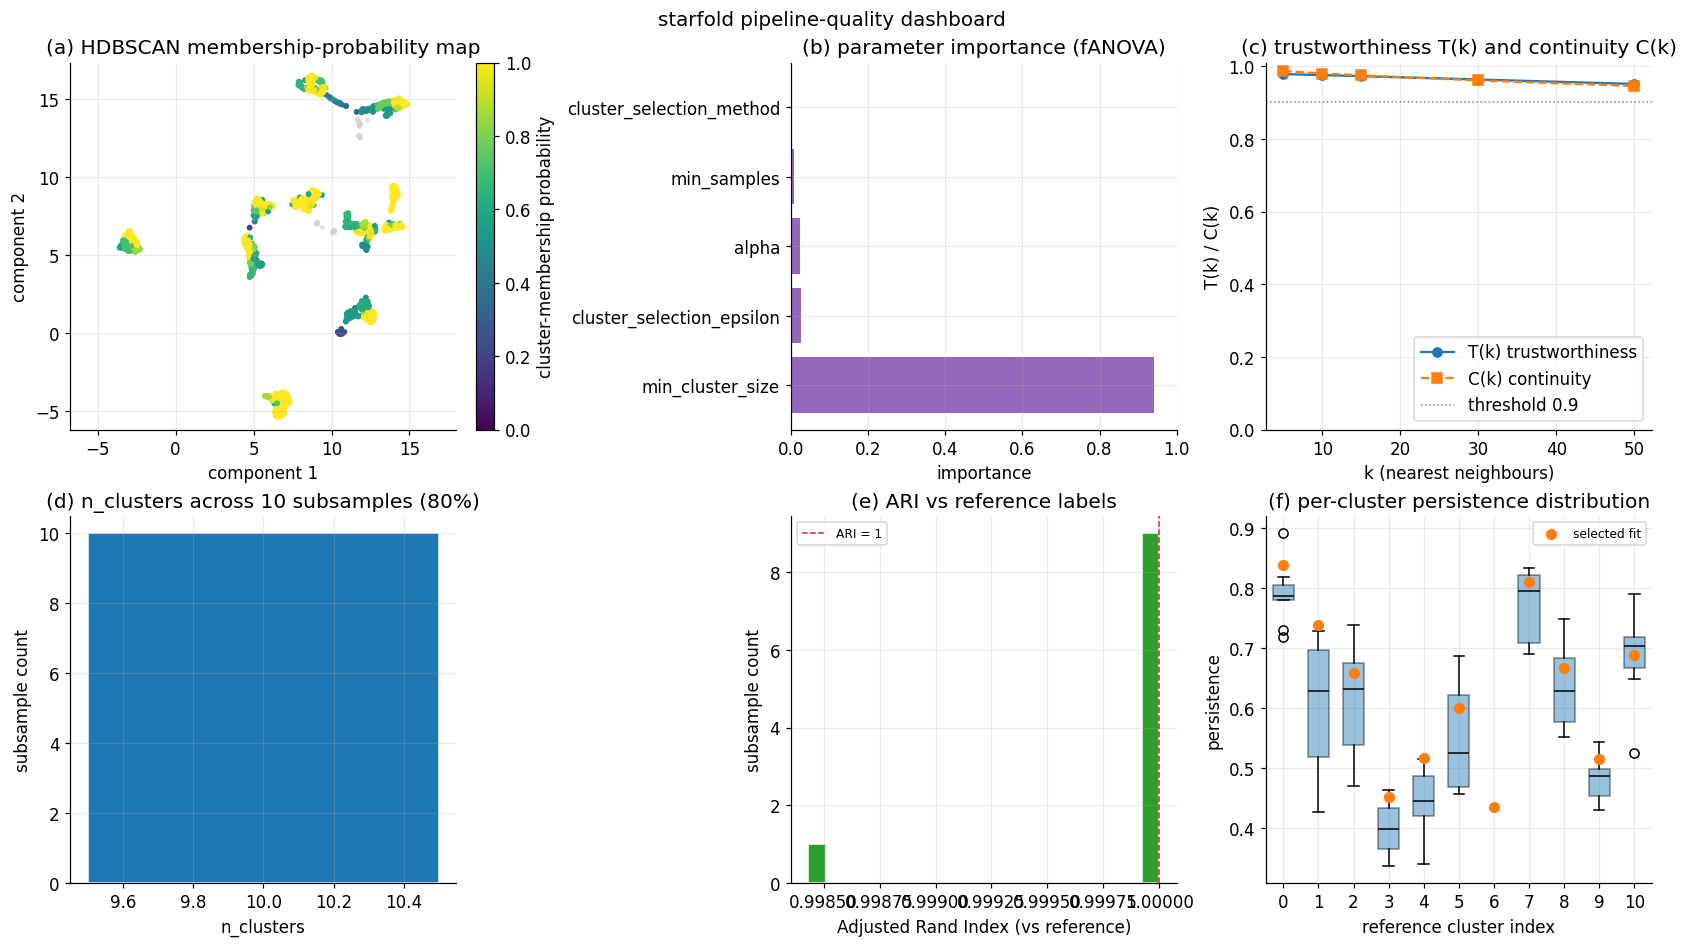

In [24]:
fig = result.plot_quality_dashboard(
    X,
    n_subsamples=10,
    subsample_fraction=0.8,
    k_values=(5, 10, 15, 30, 50),
    figsize=(15.0, 8.5),
    random_state=0,
)
fig.savefig(FIGURE_DIR / "09_quality_dashboard.png")
plt.show()

## §9. Acting on the audit: refinement

§7-§8 told us *how good* the clustering looks. The next question
is what to do when something looks off. On this dataset HDBSCAN
returned **11 clusters** but the digits have **10 true classes**,
which suggests the fit is slightly **over-split**: somewhere two
clusters share a true class. The natural action is a merge.

This section compares two ways to choose which pair to merge:

1. **Blind / algorithmic** — apply the top candidate from
   `suggest_merges()` based on density and geometry alone.
2. **Inspection-informed** — look at sample images from each
   cluster and merge the pair that visually appears to be the
   same class.

Both are computed with the same metric scorecard.

### §9a. Read the audit: `result.suggest_merges()`

Flags cluster pairs where the HDBSCAN condensed tree (density)
*and* the 2-D embedding geometry (centroid gap relative to
intra-cluster dispersion) both agree the pair should be one.
Pairs where the two heuristics disagree are kept apart on purpose.

In [25]:
candidates = result.suggest_merges()
n_recommended = sum(m.recommended for m in candidates)
print(f"{len(candidates)} candidate pairs evaluated, {n_recommended} flagged at default thresholds")
print()
print("top 5 candidates, sorted by cohesion ratio:")
print(f"  {'pair':<11} {'cohesion':>9} {'gap':>6}  recommended")
for m in candidates[:5]:
    flag = "yes" if m.recommended else "no"
    pair = f"{m.cluster_i} <-> {m.cluster_j}"
    print(f"  {pair:<11} {m.cohesion_ratio:>9.2f} {m.gap_ratio:>6.2f}  {flag}")

55 candidate pairs evaluated, 0 flagged at default thresholds

top 5 candidates, sorted by cohesion ratio:
  pair         cohesion    gap  recommended
  0 <-> 1          1.00   9.46  no
  4 <-> 5          1.00   5.88  no
  9 <-> 10         1.00   2.68  no
  3 <-> 6          0.90   8.80  no
  7 <-> 8          0.69   5.23  no


Zero recommendations at the default thresholds means the algorithm
itself does not see a safe merge. We still demonstrate the
workflow below: applying the top candidate anyway, then comparing
against an inspection-informed alternative.

### §9b. Inspect each cluster's average image

When the underlying samples are inspectable (images, audio,
spectra), a fast sanity check is the cluster *centroid in the
original feature space*: the average of every member's input
vector, reshaped back to the natural display form. Two clusters
whose centroids look like the same thing are the inspection-
candidate for merging — independent of where they happen to sit
in the 2-D embedding.

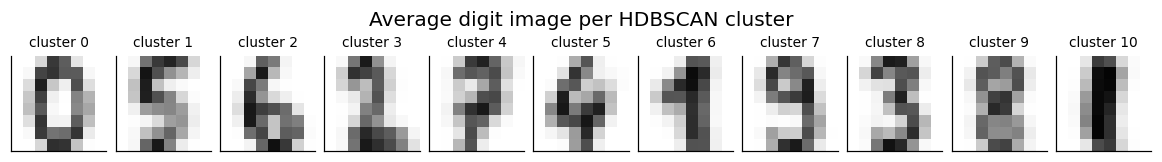

In [26]:
n_clusters = result.n_clusters
centroids = np.stack([X[result.labels == c].mean(axis=0) for c in range(n_clusters)])

fig, axes = plt.subplots(1, n_clusters, figsize=(0.95 * n_clusters, 1.4), constrained_layout=True)
for c, ax in enumerate(axes):
    ax.imshow(centroids[c].reshape(8, 8), cmap="Greys", vmin=0, vmax=16)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    ax.set_title(f"cluster {c}", fontsize=9)
fig.suptitle("Average digit image per HDBSCAN cluster", y=1.1)
fig.savefig(FIGURE_DIR / "10_cluster_average_images.png")
plt.show()

A first-time reader can read this strip directly: most clusters
show a clean digit silhouette, and a duplicate (two clusters
whose centroids both look like the digit "1") is the
inspection-candidate for merging. The 2-D embedding placed those
two clusters apart because the two writing styles really are
geometrically separated; visual inspection sees through that.

### §9c. Two refinement candidates

`apply_merge` is the same one-line helper for both strategies:
replace one cluster's label with another's and compact the result
back to `0..K-1`.

In [27]:
def apply_merge(labels: np.ndarray, cluster_src: int, cluster_dst: int) -> np.ndarray:
    """Relabel ``cluster_src`` as ``cluster_dst`` and compact the labels."""
    merged = labels.copy()
    merged[merged == cluster_src] = cluster_dst
    valid = merged >= 0
    unique = np.unique(merged[valid])
    out = np.full_like(merged, -1)
    out[valid] = np.searchsorted(unique, merged[valid])
    return out.astype(np.intp)


# Strategy A: blind, top-cohesion candidate from suggest_merges.
blind_pair = (candidates[0].cluster_i, candidates[0].cluster_j)
labels_blind = apply_merge(result.labels, blind_pair[1], blind_pair[0])
print(
    f"Strategy A (blind):              merge {blind_pair[1]} -> {blind_pair[0]}  "
    f"(cohesion={candidates[0].cohesion_ratio:.2f}, "
    f"gap={candidates[0].gap_ratio:.2f}, "
    f"recommended={candidates[0].recommended})"
)

# Strategy B: inspection-informed. With y_truth available we can
# show what "this digit class is split across two clusters" looks
# like algorithmically; without truth, the user would pick the
# duplicate pair from the centroid strip above.
from collections import Counter  # noqa: E402

dominants = np.array(
    [
        int(np.bincount(y_truth[result.labels == c], minlength=10).argmax())
        for c in range(n_clusters)
    ]
)
counts = Counter(dominants.tolist())
duplicate_digits = [d for d, n in counts.items() if n > 1]
if duplicate_digits:
    target_digit = duplicate_digits[0]
    dup_clusters = sorted(
        [c for c in range(n_clusters) if dominants[c] == target_digit],
        key=lambda c: -int((result.labels == c).sum()),
    )
    keep, drop = dup_clusters[0], dup_clusters[1]
else:
    keep = drop = blind_pair[0]
labels_informed = apply_merge(result.labels, drop, keep)
print(
    f"Strategy B (inspection-informed): merge {drop} -> {keep}  "
    f"(both centroids look like the digit '{target_digit}')"
)

Strategy A (blind):              merge 1 -> 0  (cohesion=1.00, gap=9.46, recommended=False)
Strategy B (inspection-informed): merge 6 -> 10  (both centroids look like the digit '1')


### §9d. Quantitative comparison

Four numbers tell the story. The ground-truth digit labels
(`y_truth`) are used only to **score** the clustering, not to fit
it. When no truth is available, compute the same scorecard
between two starfold runs (e.g. before and after a tuning change)
to decide whether a refinement is meaningful.

* **`n_clusters`** — closer to the true class count (10) is better.
* **ARI** (Adjusted Rand Index) — agreement with truth,
  chance-corrected. 1 is perfect, 0 is random.
* **NMI** (Normalised Mutual Information) — information-theoretic
  agreement. 1 is perfect, 0 is independent.
* **silhouette** — internal cluster compactness, no truth needed.

In [28]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score  # noqa: E402


def cluster_metrics(labels: np.ndarray, embedding: np.ndarray) -> dict[str, float | int]:
    """ARI/NMI vs ``y_truth`` plus silhouette + cluster-count summary."""
    valid = labels >= 0
    sil_res = sf.chunked_silhouette(embedding, labels, chunk_size=256)
    return {
        "n_clusters": int(len(np.unique(labels[valid]))),
        "n_outliers": int(np.sum(~valid)),
        "ARI": float(adjusted_rand_score(y_truth, labels)),
        "NMI": float(normalized_mutual_info_score(y_truth, labels)),
        "silhouette": float(sil_res.overall),
    }


before = cluster_metrics(result.labels, result.embedding)
after_blind = cluster_metrics(labels_blind, result.embedding)
after_informed = cluster_metrics(labels_informed, result.embedding)

print(f"  metric          before   blind-A   informed-B")
for key in ("n_clusters", "n_outliers", "ARI", "NMI", "silhouette"):
    b, a, c = before[key], after_blind[key], after_informed[key]
    if isinstance(b, float):
        print(f"  {key:<14}  {b:>6.3f}   {a:>7.3f}   {c:>10.3f}")
    else:
        print(f"  {key:<14}  {b:>6d}   {a:>7d}   {c:>10d}")
print()
print("  true n_clusters: 10  (digits 0-9)")

  metric          before   blind-A   informed-B
  n_clusters          11        10           10
  n_outliers          53        53           53
  ARI              0.870     0.775        0.891
  NMI              0.893     0.860        0.904
  silhouette       0.773     0.632        0.756

  true n_clusters: 10  (digits 0-9)


The blind strategy picked a high-cohesion pair that the algorithm
refused to recommend; the metrics degrade and confirm the
algorithm was right to abstain. The inspection-informed strategy
merged two clusters whose average images look like the same
digit, and the metrics improve. **Two lessons:**

1. Trust the `recommended` flag. When the algorithm abstains and
   you force a merge, expect ARI/NMI to drop.
2. When data is inspectable, augment the algorithm with visual
   inspection. The 2-D embedding can put two sub-modes of the same
   class far apart geometrically; only the original feature space
   sees that they belong together.

### §9e. Before vs after, side by side

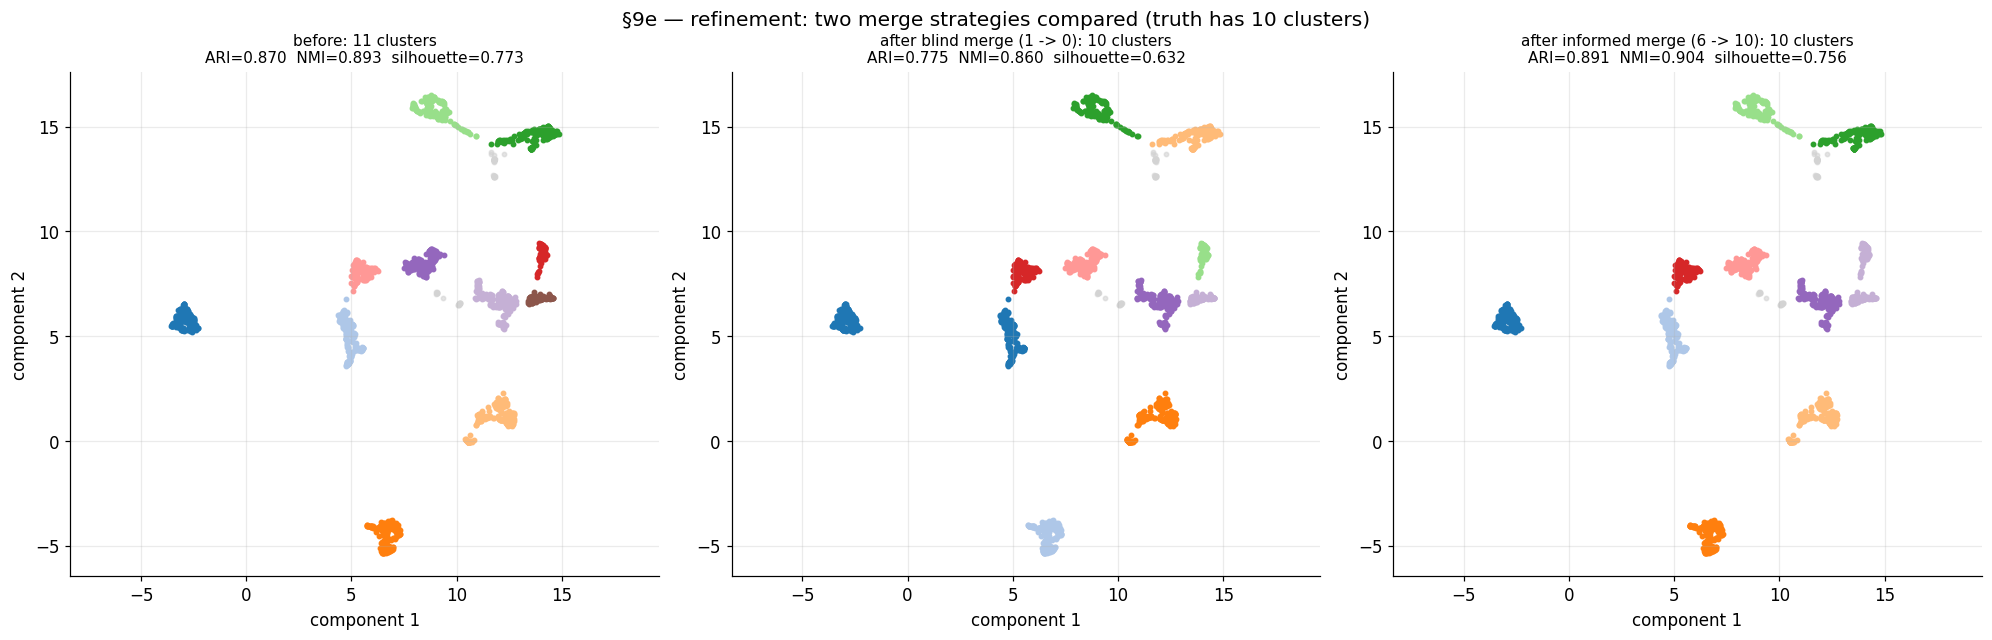

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18.0, 5.5), constrained_layout=True)
sf.plot_embedding(result.embedding, result.labels, ax=axes[0])
axes[0].set_title(
    f"before: {before['n_clusters']} clusters\n"
    f"ARI={before['ARI']:.3f}  NMI={before['NMI']:.3f}  "
    f"silhouette={before['silhouette']:.3f}",
    fontsize=10,
)
sf.plot_embedding(result.embedding, labels_blind, ax=axes[1])
axes[1].set_title(
    f"after blind merge "
    f"({blind_pair[1]} -> {blind_pair[0]}): {after_blind['n_clusters']} clusters\n"
    f"ARI={after_blind['ARI']:.3f}  NMI={after_blind['NMI']:.3f}  "
    f"silhouette={after_blind['silhouette']:.3f}",
    fontsize=10,
)
sf.plot_embedding(result.embedding, labels_informed, ax=axes[2])
axes[2].set_title(
    f"after informed merge "
    f"({drop} -> {keep}): {after_informed['n_clusters']} clusters\n"
    f"ARI={after_informed['ARI']:.3f}  NMI={after_informed['NMI']:.3f}  "
    f"silhouette={after_informed['silhouette']:.3f}",
    fontsize=10,
)
fig.suptitle(
    "§9e — refinement: two merge strategies compared (truth has 10 clusters)",
    y=1.03,
)
fig.savefig(FIGURE_DIR / "11_before_after_refinement.png")
plt.show()

### §9f. The converse direction: `result.refit_subcluster`

When the audit suggests a cluster is *under*-split (heterogeneous,
large, with visible sub-structure inside it), the converse action
is to refit the full pipeline on just that cluster's points.
`result.refit_subcluster(X, cluster_id=...)` re-standardises,
refits UMAP and Optuna-tuned HDBSCAN on the subset, and returns
a new `PipelineResult` scoped to the refinement.

This digit fit is over-split, so `refit_subcluster` is not the
right action here; it would invent spurious sub-clusters. The API
is still demonstrated in tutorial 03 where the data has a
genuinely heterogeneous parent cluster.

## §10. Input uncertainty

When the feature matrix carries per-feature 1σ error bars, two
modes are available.

### §10a. Post-hoc propagation

`result.propagate_uncertainty(X, sigma)` freezes the clean fit and
Monte Carlos the input through the trained UMAP and HDBSCAN models
(via `hdbscan.approximate_predict`). Each sample gets a
membership-probability vector and an instability scalar. The
clean clustering is unchanged; you learn which samples sit on
cluster boundaries.

In [30]:
sigma = 0.5  # pixel-intensity units; small fraction of the 0..16 range
propagation = result.propagate_uncertainty(
    X,
    sigma=sigma,
    n_draws=40,
    random_state=0,
)
print(
    f"instability range: "
    f"min={propagation.instability.min():.3f}, "
    f"median={float(np.median(propagation.instability)):.3f}, "
    f"max={propagation.instability.max():.3f}"
)
print(
    f"confident samples (instability < 0.10): "
    f"{int(np.sum(propagation.instability < 0.10))} / "
    f"{len(propagation.instability)}"
)

instability range: min=0.000, median=0.000, max=0.650
confident samples (instability < 0.10): 1753 / 1797


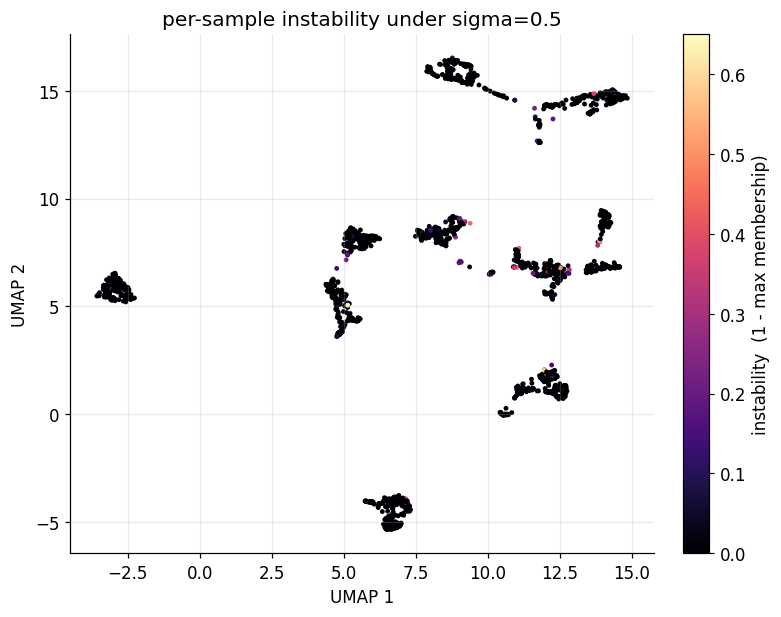

In [31]:
fig, ax = plt.subplots(figsize=(7.0, 5.5), constrained_layout=True)
sf.plot_uncertainty_map(result.embedding, propagation, ax=ax)
ax.set_title(f"per-sample instability under sigma={sigma}")
fig.savefig(FIGURE_DIR / "12_uncertainty_map.png")
plt.show()

### §10b. Uncertainty-aware fit

`pipeline.fit_with_uncertainty(X, sigma, n_replicas)` feeds an
augmented matrix (clean samples + Gaussian replicas) through the
full pipeline. UMAP and HDBSCAN see the spread itself, so the
noise baseline and credibility test are computed against the
enlarged sample.

In [32]:
aware = pipeline.fit_with_uncertainty(X, sigma=sigma, n_replicas=3)
print(
    f"aware-fit clusters: {aware.augmented_result.n_clusters} (clean-fit was {result.n_clusters})"
)
print(f"aware-fit trustworthiness: {aware.augmented_result.trustworthiness:.4f}")

aware-fit clusters: 90 (clean-fit was 11)
aware-fit trustworthiness: 0.9828


Mode A vs Mode B answer different questions: A is "given the
clustering I trust, how robust is each sample's assignment under
input noise?"; B is "what clustering does the data support when
its uncertainty is part of the fit?".

### §10c. A topology-stress test: torus chain with growing uncertainty

Well-separated blobs are an easy case for uncertainty propagation:
as long as `sigma` stays smaller than the inter-cluster gap, the
membership matrix is near one-hot and the instability map is dark.
The interesting regime is when neighbouring structures are
*topologically interconnected* and a growing `sigma` blurs the
boundary between them. The membership probability matrix is exactly
how we *quantify the reliability* of each sample's assignment in
that regime.

Build a four-torus closed Hopf chain in 3-D: adjacent rings thread
each other's holes, non-adjacent rings do not link. Augment with two
heteroscedastic "metadata" features at very different scales to make
the problem 5-D. The metadata is uncorrelated noise, so a real
pipeline should learn to rely on the three spatial features for the
clustering. The per-feature `sigma` vector reflects what a measurer
would actually report: small uncertainty on the precise features,
larger on the loose ones.

In [33]:
import sys  # noqa: PLC0415

for _candidate in (Path("examples"), Path("../examples"), Path.cwd() / "examples"):
    if (_candidate / "torus_chain.py").exists():
        sys.path.insert(0, str(_candidate.resolve()))
        break
from torus_chain import make_torus_chain  # noqa: E402

X_torus3, y_torus = make_torus_chain(
    n_links=4,
    points_per_link=500,
    big_radius=4.0,
    major_even=2.0,
    major_odd=2.5,
    minor_radius=0.30,
    noise_std=0.01,
    solid=True,
    random_state=0,
)

# Add two extra features at deliberately mismatched scales so the
# per-feature sigma vector has something to distinguish.
rng_5d = np.random.default_rng(1)
extra_a = rng_5d.normal(0.0, 0.05, size=X_torus3.shape[0])  # very precise
extra_b = rng_5d.normal(0.0, 30.0, size=X_torus3.shape[0])  # very loose
X_torus = np.column_stack([X_torus3, extra_a, extra_b])

# Per-feature one-sigma measurement uncertainty. Spatial coords are
# precise (think positions); extra_a is also precise; extra_b is
# loose (think a poorly constrained derived quantity). These are
# baseline values; we will scale them in a moment.
sigma_baseline = np.array([0.05, 0.05, 0.05, 0.02, 10.0])

print(f"X shape:           {X_torus.shape}")
print(f"feature ranges:")
ranges = X_torus.max(axis=0) - X_torus.min(axis=0)
for j, (rng_, sig) in enumerate(zip(ranges, sigma_baseline, strict=False)):
    print(
        f"  feat_{j}: range={rng_:8.2f}   sigma_baseline={sig:7.2f}   sigma/range={sig / rng_:6.1%}"
    )

X shape:           (2000, 5)
feature ranges:
  feat_0: range=    8.59   sigma_baseline=   0.05   sigma/range=  0.6%
  feat_1: range=   13.49   sigma_baseline=   0.05   sigma/range=  0.4%
  feat_2: range=    4.54   sigma_baseline=   0.05   sigma/range=  1.1%
  feat_3: range=    0.37   sigma_baseline=   0.02   sigma/range=  5.5%
  feat_4: range=  206.69   sigma_baseline=  10.00   sigma/range=  4.8%


Look at the 3-D chain coloured by ring label. Adjacent rings
interlock through each other; far-side rings do not touch.

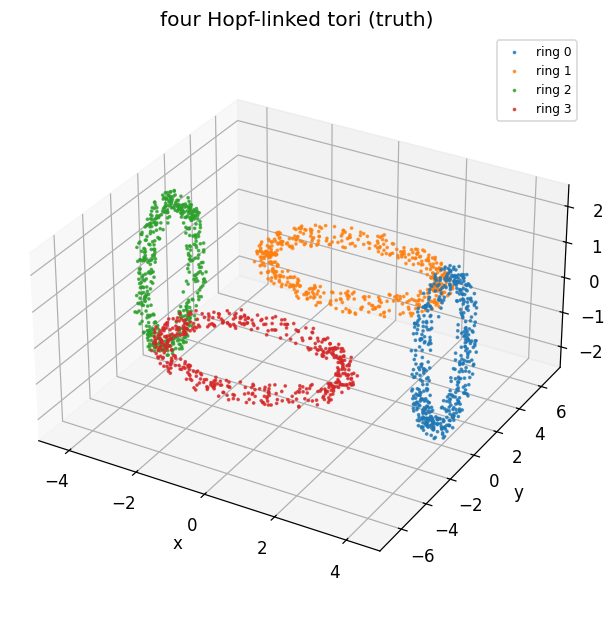

In [34]:
fig = plt.figure(figsize=(7.0, 5.5), constrained_layout=True)
ax3d = fig.add_subplot(111, projection="3d")
cmap_chain = plt.get_cmap("tab10")
for k in range(int(y_torus.max()) + 1):
    m = y_torus == k
    ax3d.scatter(
        X_torus[m, 0],
        X_torus[m, 1],
        X_torus[m, 2],
        s=2.0,
        color=cmap_chain(k),
        alpha=0.75,
        label=f"ring {k}",
    )
ax3d.set_xlabel("x")
ax3d.set_ylabel("y")
ax3d.set_zlabel("z")
ax3d.set_title("four Hopf-linked tori (truth)")
ax3d.set_box_aspect((1, 1, 0.55))
ax3d.legend(fontsize=8, loc="upper right")
fig.savefig(FIGURE_DIR / "13_torus_chain_truth.png")
plt.show()

Fit the pipeline once on the observed matrix. Each ring should land
as its own cluster (HDBSCAN may split a torus into two arcs because
UMAP cannot embed a circle in 2-D without tearing; that is a known
topology artefact, not an uncertainty effect).

In [35]:
pipeline_torus = sf.UnsupervisedPipeline(
    umap_kwargs={"n_neighbors": 30, "min_dist": 0.0, "n_epochs": 500},
    hdbscan_optuna_trials=40,
    mcs_range=(60, 400),
    ms_range=(5, 30),
    skip_noise_baseline=True,
    random_state=0,
)
result_torus = pipeline_torus.fit(X_torus)
print(result_torus.summary())

!! diagnostic flags
--------------------------------
- Optuna best was reached 32 trials before the end of the 40-trial budget; consider halving n_trials on similar runs to save compute.

starfold pipeline result
--------------------------------
n_samples        2000
n_clusters       6
n_outliers       6  (0.3%)
trustworthiness  0.9781
continuity       0.9584
objective        persistence_sum
best_params      {'min_cluster_size': 156, 'min_samples': 30, 'cluster_selection_method': 'leaf', 'cluster_selection_epsilon': 0.0593778986324672, 'alpha': 1.1912241192535378}
persistence_sum  3.6949
persistence_med  0.6692
DBCV (MST proxy) 0.4525
persistence      [0.703 0.659 0.727 0.68  0.462 0.465]


/tmp/ipykernel_1661227/1716263483.py:9: UserWarning: Optuna best was reached 32 trials before the end of the 40-trial budget; consider halving n_trials on similar runs to save compute.
  result_torus = pipeline_torus.fit(X_torus)


#### The sigma sweep

Run `propagate_uncertainty` three times, scaling the baseline
`sigma` vector by 1x, 5x, and 15x. At 1x, each sample's membership
row should be nearly one-hot. At 15x, the perturbations are large
enough to push samples across ring boundaries: the membership
matrix smears out and the instability map lights up at exactly the
link regions where adjacent tori thread each other.

In [36]:
scales = [1.0, 5.0, 15.0]
propagations: list[sf.uncertainty.UncertaintyPropagation] = []
for s in scales:
    prop = result_torus.propagate_uncertainty(
        X_torus,
        sigma=sigma_baseline * s,
        n_draws=80,
        random_state=0,
    )
    propagations.append(prop)
    n_clusters = prop.membership.shape[1] - 1
    print(
        f"sigma x{s:>4.1f}:  mean instability = {prop.instability.mean():.3f}   "
        f"frac confident (instab<0.1) = {(prop.instability < 0.10).mean():.1%}   "
        f"frac high-doubt (instab>0.5) = {(prop.instability > 0.50).mean():.1%}"
    )

sigma x 1.0:  mean instability = 0.011   frac confident (instab<0.1) = 96.4%   frac high-doubt (instab>0.5) = 0.0%


sigma x 5.0:  mean instability = 0.071   frac confident (instab<0.1) = 78.0%   frac high-doubt (instab>0.5) = 0.3%


sigma x15.0:  mean instability = 0.317   frac confident (instab<0.1) = 17.8%   frac high-doubt (instab>0.5) = 18.7%


Visualise the breakdown. Left: the clean embedding coloured by
label. Right three panels: instability map at growing sigma. Watch
how the bright "uncertain" regions concentrate at the link points
between adjacent rings as sigma grows, then engulf entire rings.

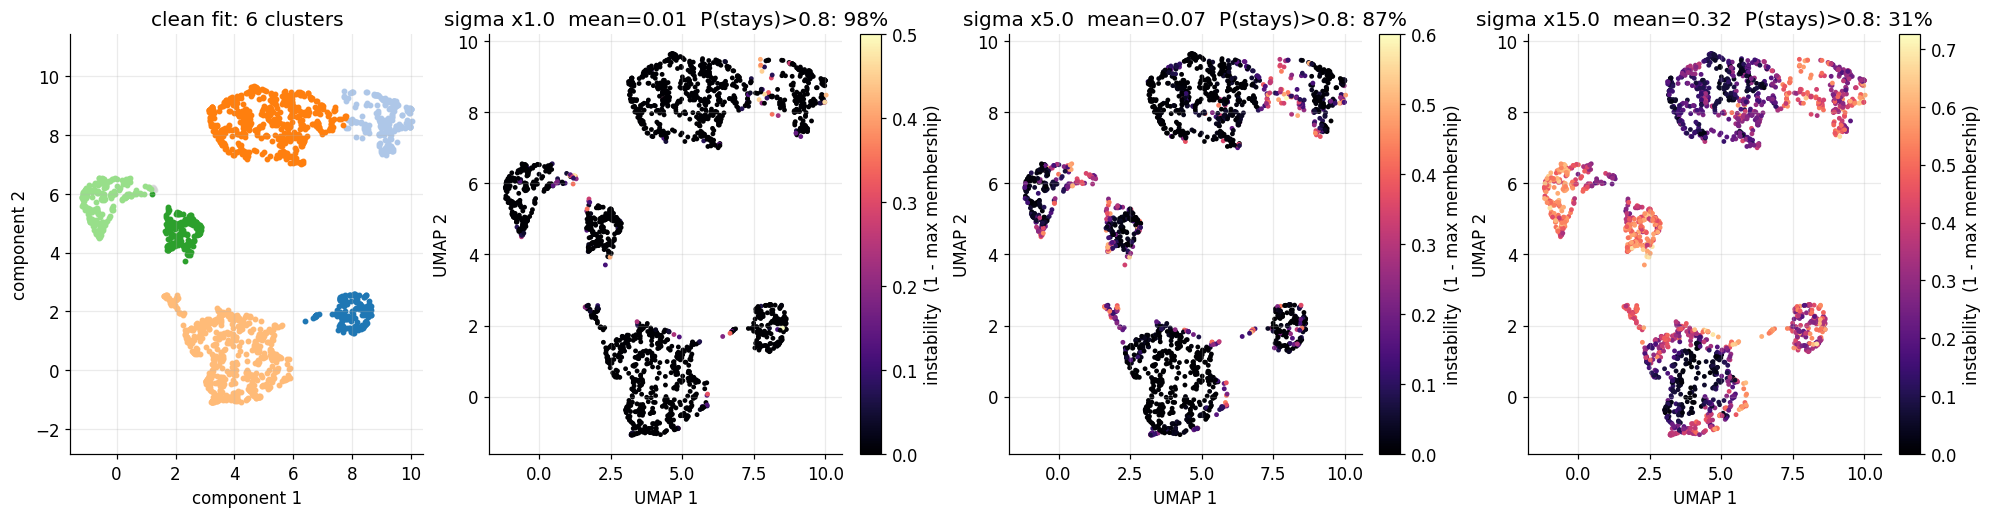

In [37]:
fig, axes = plt.subplots(1, 4, figsize=(18.0, 4.6), constrained_layout=True)
sf.plot_embedding(result_torus.embedding, result_torus.labels, ax=axes[0])
axes[0].set_title(f"clean fit: {result_torus.n_clusters} clusters")
for ax, scale, prop in zip(axes[1:], scales, propagations, strict=True):
    sf.plot_uncertainty_map(result_torus.embedding, prop, ax=ax)
    ax.set_title(
        f"sigma x{scale:.1f}  mean={prop.instability.mean():.2f}  "
        f"P(stays)>0.8: {(prop.instability < 0.20).mean():.0%}"
    )
fig.savefig(FIGURE_DIR / "14_torus_uncertainty_sweep.png")
plt.show()

#### Per-sample reliability: same boundary sample, three sigma regimes

Pick the sample with the highest instability at the largest sigma.
Track its membership row across the three regimes. This is the
quantitative answer to "how reliable is this sample's cluster
assignment given the input uncertainty?"

In [38]:
worst_idx = int(np.argmax(propagations[-1].instability))
n_cols = propagations[0].membership.shape[1]
header = [f"P(c{k})" for k in range(n_cols - 1)] + ["P(out)"]
print(
    f"sample {worst_idx} (hard label = {int(result_torus.labels[worst_idx])}, "
    f"true ring = {int(y_torus[worst_idx])})"
)
print(f"  {'sigma':>8}  {'instab.':>8}  " + "  ".join(f"{h:>6}" for h in header))
for scale, prop in zip(scales, propagations, strict=True):
    row = prop.membership[worst_idx]
    probs = "  ".join(f"{p:>6.2f}" for p in row)
    print(f"  x{scale:>5.1f}    {prop.instability[worst_idx]:>8.3f}  {probs}")

sample 214 (hard label = 4, true ring = 0)
     sigma   instab.   P(c0)   P(c1)   P(c2)   P(c3)   P(c4)   P(c5)  P(out)
  x  1.0       0.000    0.00    0.00    0.00    0.00    1.00    0.00    0.00
  x  5.0       0.125    0.00    0.00    0.01    0.10    0.88    0.00    0.01
  x 15.0       0.725    0.00    0.00    0.28    0.26    0.25    0.01    0.20


At low sigma the row is concentrated on one cluster. At high
sigma, probability mass spreads across several clusters (and the
outlier column), which is the *reliability quantification* the
user asked for: a probability distribution over cluster identities
rather than a hard label.

Per-cluster aggregates tell the same story at the group level: as
sigma grows, the median `P(stays)` for each ring drops, and the
fraction of confident samples (instability < 0.1) collapses.

In [39]:
print(
    f"{'cluster':>8}  {'size':>5}  "
    + "  ".join(f"{'P_stay@x' + str(s):>10}" for s in [1.0, 5.0, 15.0])
    + "  "
    + "  ".join(f"{'conf@x' + str(s):>9}" for s in [1.0, 5.0, 15.0])
)
for k in range(result_torus.n_clusters):
    mask = result_torus.labels == k
    if not mask.any():
        continue
    line = f"{k:>8}  {int(mask.sum()):>5}"
    for prop in propagations:
        line += f"  {np.median(prop.membership[mask, k]):>10.3f}"
    for prop in propagations:
        line += f"  {(prop.instability[mask] < 0.10).mean():>9.1%}"
    print(line)

 cluster   size  P_stay@x1.0  P_stay@x5.0  P_stay@x15.0  conf@x1.0  conf@x5.0  conf@x15.0
       0    179       1.000       0.988       0.613      96.6%      76.0%       0.0%
       1    238       1.000       0.963       0.613      92.4%      70.2%       0.0%
       2    557       1.000       1.000       0.825      98.7%      87.8%      29.6%
       3    596       1.000       1.000       0.762      97.3%      86.2%      32.2%
       4    189       1.000       0.963       0.388      95.2%      63.0%       0.0%
       5    235       1.000       0.925       0.362      95.3%      57.9%       0.0%


#### Uncertainty-aware fit on the high-sigma regime

At the highest sigma the post-hoc analysis says "boundaries are
unreliable, treat half the assignments as uncertain". The next
question is what clustering the *pipeline* itself would produce
if it saw the uncertainty cloud during fitting. Run
`fit_with_uncertainty` at the same 15x sigma with three replicas.
If adjacent rings truly become indistinguishable to UMAP+HDBSCAN
under that noise level, the aware fit returns fewer clusters than
the clean fit.

In [40]:
aware_torus = pipeline_torus.fit_with_uncertainty(
    X_torus,
    sigma=sigma_baseline * 15.0,
    n_replicas=3,
)
print(f"{'metric':<22} {'clean fit':>10}  {'aware fit (x15)':>17}")
print(
    f"{'n_clusters':<22} {result_torus.n_clusters:>10d}  "
    f"{aware_torus.augmented_result.n_clusters:>17d}"
)
print(
    f"{'trustworthiness':<22} {result_torus.trustworthiness:>10.4f}  "
    f"{aware_torus.augmented_result.trustworthiness:>17.4f}"
)
print(
    f"{'mean instability':<22} {float(propagations[-1].instability.mean()):>10.3f}  "
    f"{float(aware_torus.propagation.instability.mean()):>17.3f}"
)

metric                  clean fit    aware fit (x15)
n_clusters                      6                 48
trustworthiness            0.9781             0.9766
mean instability            0.317              0.547


/home/aneitzel/projects/starfold/src/starfold/pipeline.py:1016: UserWarning: Optuna best was reached 32 trials before the end of the 40-trial budget; consider halving n_trials on similar runs to save compute.
  augmented_result = self.fit(x_aug)


Mode A (post-hoc, the three panels above) and mode B
(`fit_with_uncertainty`) answer different questions. Mode A
*audits* the clean fit: "given this clustering, how stable is each
label?". Mode B *renegotiates* the clustering itself: "what
structure does the data support when its uncertainty cloud is part
of the fitting input?".

The two modes can disagree directionally and *that disagreement is
itself a signal*. At low sigma the rings stay clearly separated in
both modes. At very large sigma mode B does not necessarily produce
fewer clusters than the clean fit; on a Hopf chain at x15 the
augmented matrix carries so many perturbation-driven density
splinters that HDBSCAN fragments into tens of micro-clusters around
the chain. Mode A says "boundaries are smeared, treat them with
care" via the membership matrix; mode B says "the density landscape
itself is unstable" via an inflated, run-to-run-varying cluster
count. Both are reasons to distrust the hard label. The right
action in either case is the same: filter on
`propagation.confident_labels(threshold=0.8)` and report the
membership matrix alongside the hard assignments rather than the
hard assignments alone.

## §11. Save and reload

`result.save(directory)` writes the embedding, labels, persistence,
trustworthiness, fitted scaler and reducer, run config, and (when
present) the noise baseline summary and credibility report.
`sf.load_pipeline_result(directory)` returns the same content as a
dict (the Optuna study is not rehydrated; see the docstring).

In [41]:
import tempfile  # noqa: E402

with tempfile.TemporaryDirectory() as tmp:
    run_dir = Path(tmp) / "walkthrough_run"
    saved_path = result.save(run_dir)
    files = sorted(p.name for p in saved_path.iterdir())
    print(f"saved {len(files)} files: {files}")
    loaded = sf.load_pipeline_result(run_dir)

assert np.array_equal(loaded["labels"], result.labels)
assert np.allclose(loaded["embedding"], result.embedding, atol=0.0)
print("round-trip OK: labels and embedding are bit-identical")

saved 2 files: ['arrays.npz', 'meta.json']
round-trip OK: labels and embedding are bit-identical


`save_pipeline_result(result, directory)` is the free-function
counterpart of the method.

## §12. Where to next

Every public function in `starfold.__all__` has been demonstrated
in this notebook. For deeper coverage of a specific topic:

* **[`tutorial_01_quickstart.ipynb`](tutorial_01_quickstart.ipynb)**
  — a stripped-down end-to-end pass on a topologically non-trivial
  synthetic dataset (8-torus chain).
* **[`tutorial_02_validation.ipynb`](tutorial_02_validation.ipynb)**
  — noise baseline and credibility test at production budgets;
  tuning and quality dashboards explained panel by panel.
* **[`tutorial_03_advanced.ipynb`](tutorial_03_advanced.ipynb)**
  — refinement workflow in detail: silhouette, merge recommender,
  sub-cluster refit, and both uncertainty modes side-by-side.
* **[`tutorial_04_astronomy.ipynb`](tutorial_04_astronomy.ipynb)**
  — a real-data case study on 9 242 Milky Way stars from APOGEE
  DR19 and Gaia DR3, bundled as a 0.5 MB parquet so no survey
  download is needed.

For the methodology background, `docs/methodology.md` rewrites
paper §3 (the core pipeline) and §§6-9 (the extensions) for
non-astronomers. For every place where the paper is silent on a
default, see `docs/design_decisions.md`.